In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
kanser_verisi = load_breast_cancer()

df = pd.DataFrame(kanser_verisi.data, columns=kanser_verisi.feature_names)

df['Hedef'] = kanser_verisi.target

print(f"Tablo Boyutu: {df.shape}")
df.head()

Tablo Boyutu: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Hedef
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


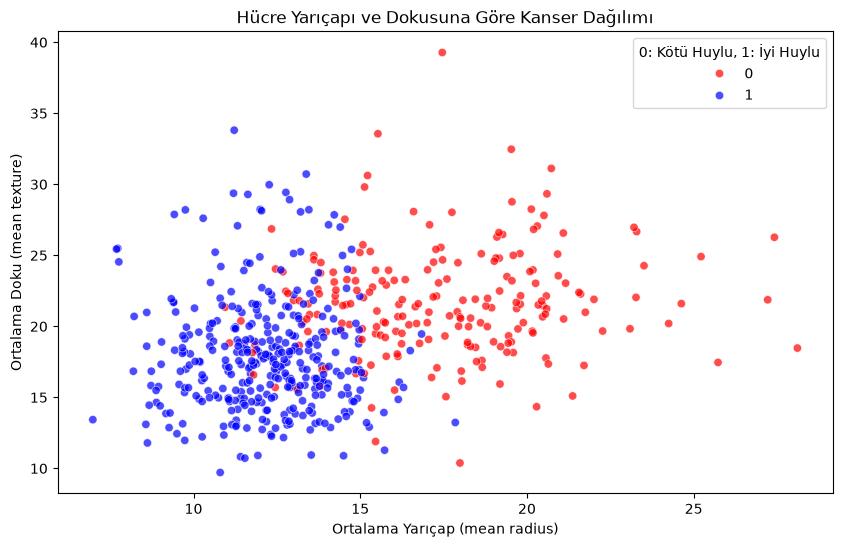

In [4]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df['mean radius'], 
    y=df['mean texture'], 
    hue=df['Hedef'], 
    palette=['red', 'blue'], # 0 (Kötü Huylu) Kırmızı, 1 (İyi Huylu) Mavi olsun
    alpha=0.7
)

plt.title('Hücre Yarıçapı ve Dokusuna Göre Kanser Dağılımı')
plt.xlabel('Ortalama Yarıçap (mean radius)')
plt.ylabel('Ortalama Doku (mean texture)')
plt.legend(title='0: Kötü Huylu, 1: İyi Huylu')
plt.show()

In [6]:
X = df.drop('Hedef', axis=1)
y = df['Hedef']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_olcekli = scaler.fit_transform(X_train)
X_test_olcekli = scaler.transform(X_test)

In [8]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_olcekli, y_train)

tahminler_knn = knn_model.predict(X_test_olcekli)

basari_knn = accuracy_score(y_test, tahminler_knn)
print(f"KNN (K=5) Modelinin Doğruluk Oranı: %{basari_knn * 100:.2f}")

KNN (K=5) Modelinin Doğruluk Oranı: %94.74


In [15]:
# Hiperparametre Optimizasyonu (Hyperparameter Tuning)
score_list = []
for each in range(1,15):
    knn = KNeighborsClassifier(n_neighbors=each)
    knn.fit(X_train_olcekli, y_train)
    score_list.append(knn.score(X_test_olcekli, y_test))


In [12]:
score_list

[0.9385964912280702,
 0.9385964912280702,
 0.9473684210526315,
 0.956140350877193,
 0.9473684210526315,
 0.956140350877193,
 0.9473684210526315,
 0.956140350877193,
 0.9649122807017544,
 0.956140350877193,
 0.956140350877193,
 0.956140350877193,
 0.956140350877193,
 0.956140350877193]

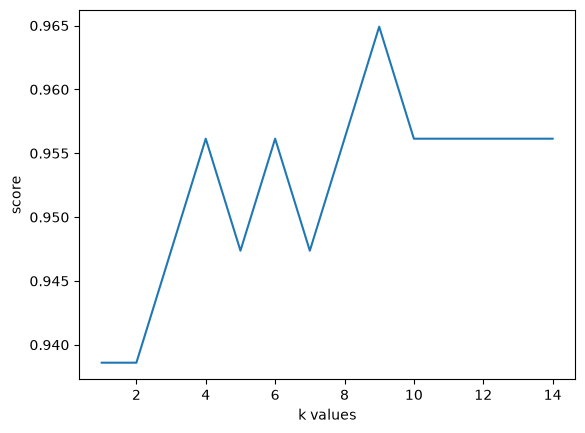

In [14]:
plt.plot(range(1,15),score_list)
plt.xlabel("k values")
plt.ylabel("score")
plt.show()